In [6]:


from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    tr=2.1,
    task="sleep",
    load_signal=True, 
    # desc_add="raw",
    ignore_boundary_trs=0,
    load_eog=False,
)




Per-run correlations (163 runs):
9.78300762841918 [0.22427714 0.33508517]


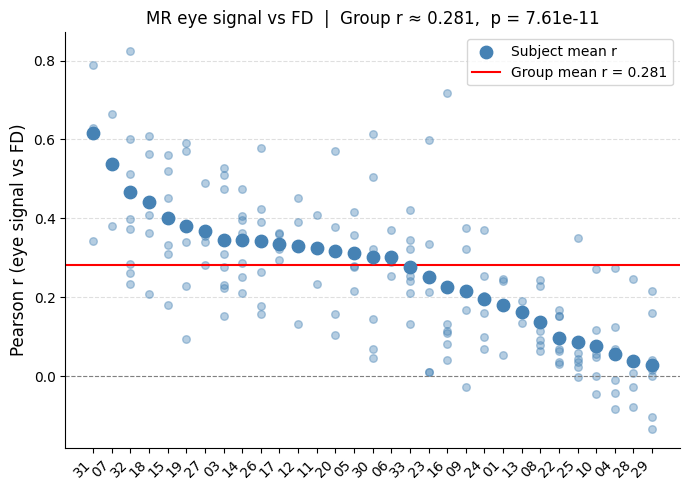

In [7]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ── 1. Collect per-run correlations ──────────────────────────────────────────

records = []

for subject, run, run_df in mrio.iter_run_events():
    eye_signal = run_df["mreyemove"]

    # It's called conv just because this is the regressor name
    # It's only convolved in glm.first_level so it's the preprocessed signal here
    fd_rows = run_df["conv_framewise_displacement"] 
    if fd_rows.isna().any():
        print(f"  Skipping {subject} run {run} (no FD data)")
        continue

    fd_signal = fd_rows.values.astype(float)

    if len(eye_signal) != len(fd_signal):
        print(f"  Skipping {subject} run {run} (length mismatch: eye={len(eye_signal)}, FD={len(fd_signal)})")
        continue

    r, _ = stats.pearsonr(eye_signal, fd_signal)  
    if np.isnan(r):
        continue

    records.append(dict(
        subject=subject,
        run=run,
        r=r,
        n=len(eye_signal),
        mean_eye=np.mean(np.abs(eye_signal)),
        mean_eog=np.mean(np.abs(fd_signal)),
    ))

run_df = pd.DataFrame(records)
print(f"\nPer-run correlations ({len(run_df)} runs):")

# ── 2. Per-subject average r (Fisher z then back) ────────────────────────────

def fisher_mean_z(r_values):
    """Return Fisher-averaged correlation in z-space."""
    return np.mean(np.arctanh(np.clip(r_values, -0.9999, 0.9999)))

subj_df = (
    run_df.groupby("subject")["r"]
    .agg(z=lambda _r: fisher_mean_z(_r.values), n_runs="count")
    .reset_index()
)
subj_df["r"] = np.tanh(subj_df["z"])  # for display only


# Group-level

z_vals = subj_df["z"].values
mean_z = z_vals.mean()

group_r = np.tanh(mean_z)

t_stat, p_val = stats.ttest_1samp(subj_df["z"].values, 0)
se_z = subj_df["z"].std(ddof=1) / np.sqrt(len(subj_df))
ci_z = mean_z + np.array([-1, 1]) * stats.t.ppf(0.975, len(subj_df)-1) * se_z
ci_r = np.tanh(ci_z)  # e.g. report group r = 0.017, 95% CI [...]

print(t_stat, ci_r)
# ── 4. Plot: per-subject mean r with individual runs ─────────────────────────

subj_plot = subj_df.sort_values("r", ascending=False).reset_index(drop=True)
p_str = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"

fig, ax = plt.subplots(figsize=(7, 5))

for i, row in subj_plot.iterrows():
    runs = run_df[run_df["subject"] == row["subject"]]["r"].values
    ax.scatter([i] * len(runs), runs, color="steelblue", alpha=0.4, s=30, zorder=2)

ax.scatter(range(len(subj_plot)), subj_plot["r"],
           color="steelblue", s=80, zorder=3, label="Subject mean r")

ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(group_r, color="red", lw=1.5, ls="-", label=f"Group mean r = {group_r:.3f}")

ax.set_xticks(range(len(subj_plot)))
ax.set_xticklabels(subj_plot["subject"].str.replace("sub-", ""), rotation=45, ha="right")
ax.set_ylabel("Pearson r (eye signal vs FD)", fontsize=12)
ax.set_title(f"MR eye signal vs FD  |  Group r ≈ {group_r:.3f},  p = {p_str}", fontsize=12)
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/Users/zach/2025_RA/matthias/final images/correlations/mreyemove_fd_r_per_subject.svg", dpi=300)
plt.show()

In [17]:
from scipy.stats import ttest_1samp

from scipy.stats import zscore

l1 = "W"
l2 = "S"

def create_blocks(arr, trim: int):
    # Get indices where values are not NaN
    valid = ~np.isnan(arr)
    # Find contiguous blocks
    changes = np.diff(valid.astype(int))
    block_starts = np.where(changes == 1)[0] + 1
    block_ends = np.where(changes == -1)[0] + 1
    
    # Handle edge cases where array starts/ends with valid values
    if valid[0]:
        block_starts = np.concatenate([[0], block_starts])
    if valid[-1]:
        block_ends = np.concatenate([block_ends, [len(arr)]])
    
    blocks = [arr[s+trim:e-trim] for s, e in zip(block_starts, block_ends) 
          if (e - trim) - (s + trim) > 0]
    return blocks



def permute_labels(blocks):
    labels = [l for _, l in blocks]
    np.random.shuffle(labels)
    return [(b, l) for (b, _), l in zip(blocks, labels)]




subject_blocks = {}
for subject in mrio.subjects:
    blocks = []
    
    # For each run, get contiguous sleep and wake blocks,
    # trimming the edge TRs off
    for _, run, run_df in mrio.iter_run_events(subject=subject):
        eye_signal = run_df["conv_framewise_displacement"]
        wake = np.full_like(eye_signal, np.nan)
        wake[run_df[l1]] = eye_signal[run_df[l1]]
        for block in create_blocks(wake, trim=1):
            blocks.append((block, l1))
        
        sleep = np.full_like(eye_signal, np.nan)
        sleep[run_df[l2]] = eye_signal[run_df[l2]]
        for block in create_blocks(sleep, trim=1):
            blocks.append((block, l2))
    
    subject_blocks[subject] = blocks
        
subject_blocks = {
    s: blocks for s, blocks in subject_blocks.items()
    if any(l == l2 for _, l in blocks)  
}
    

def compute_statistic(blocks, stat, l1, l2):
    """
    Compute statistic per subject
    Find the difference in descriptors for each state using all 
    contiguous state blocks across runs 
    Parameters
    ----------
    blocks
    stat

    Returns
    -------

    """
    wake_vals = np.concatenate([b for b, l in blocks if l == l1])
    sleep_vals = np.concatenate([b for b, l in blocks if l == l2])
    if stat == "mean":
        return np.mean(wake_vals) - np.mean(sleep_vals)
    elif stat == "std":
        return np.std(wake_vals) - np.std(sleep_vals)
    elif stat == "count":
        return len(wake_vals) - len(sleep_vals)
    elif stat == "median":
        return np.median(wake_vals) - np.median(sleep_vals)
    elif stat == "iqr":
        return np.percentile(wake_vals, 75) - np.percentile(sleep_vals, 25)

def permutation_test2(subject_blocks, stat, n_permutations=10000):
    subjects = list(subject_blocks.keys())
    
    subj_zs = []
    means = []
    for subject in subjects:
        subj_null_distribution = []
        for _ in range(n_permutations):
            perm_stats = np.array([
                compute_statistic(permute_labels(subject_blocks[subject]), stat, l1, l2) 
            ])
            subj_null_distribution.append(np.mean(perm_stats))
        shuffled_mean = np.mean(subj_null_distribution)
        shuffled_std = np.std(subj_null_distribution)
        observed_mean = compute_statistic(subject_blocks[subject], stat, l1, l2)
        
        subj_z = (observed_mean - shuffled_mean) / shuffled_std
        subj_zs.append(subj_z)
        means.append(observed_mean)
    return np.mean(subj_zs), subj_zs, np.mean(means)


from scipy.stats import f_oneway

# Run tests
# results_mean = permutation_test(subject_blocks, stat="mean", n_permutations=10000)
# results_median = permutation_test(subject_blocks, stat="median", n_permutations=10000)
# results_var  = permutation_test(subject_blocks, stat="var", n_permutations=10000)

print("Count")
mean_zs, zs, obs  = permutation_test2(subject_blocks, stat="count", n_permutations=10000)
print(ttest_1samp(zs, 0, alternative="two-sided"), mean_zs)
print(obs)


print("Mean")
mean_zs, zs, obs  = permutation_test2(subject_blocks, stat="mean", n_permutations=10000)
print(ttest_1samp(zs, 0, alternative="two-sided"), mean_zs)
print(obs)

print("Std")
mean_zs, zs, obs  = permutation_test2(subject_blocks, stat="std", n_permutations=10000)
print(ttest_1samp(zs, 0, alternative="two-sided"), mean_zs)
print(obs)
# print(compute_statistic(subject_blocks, stat="mean", l1=l1, l2=l2))


Count
TtestResult(statistic=-1.4330736414054857, pvalue=0.1621766003786621, df=30) -0.4510974919769752
-69.96774193548387
Mean
TtestResult(statistic=3.2588084179930323, pvalue=0.0027817756211892313, df=30) 0.9817450984466928
0.0497435943903461
Std
TtestResult(statistic=4.069588870284811, pvalue=0.0003152678285423983, df=30) 0.9256824215976907
0.12745900713009595


In [6]:
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    tr=2.1,
    task="sleep",
    desc_add="clean",
)




EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping


In [18]:
from SleepMReye.plotting import plot_surface_searchlight
from pathlib import Path
from nilearn.image import new_img_like
from mreyemove.plotting.glm import plot_img_on_surf_with_contour, custom_cmap
from mreyemove.analysis.searchlight_correlation import run_fsaverage_surface_searchlight_correlation
from mreyemove.analysis.searchlight_correlation import build_fsaverage_neighborhoods
import nibabel as nib


# --- Run searchlight and plot ---
radius_mm = 38  # geodesic radius in mm
surf_mesh = "fsaverage7"

neighborhoods = build_fsaverage_neighborhoods(surf_mesh=surf_mesh, radius_mm=radius_mm)
corr_maps = {}
window_size = 3 


[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Building geodesic neighborhoods (radius=38mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 2230, Median: 2164, Min: 799, Max: 4393
Building geodesic neighborhoods (radius=38mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 2272, Median: 2208, Min: 865, Max: 4762


In [22]:
from SleepMReye.plotting import plot_surface_searchlight
from pathlib import Path
from nilearn.image import new_img_like
from mreyemove.plotting.glm import plot_img_on_surf_with_contour, custom_cmap
from mreyemove.analysis.searchlight_correlation import run_fsaverage_surface_searchlight_correlation
from mreyemove.analysis.searchlight_correlation import build_fsaverage_neighborhoods
import nibabel as nib

threshold = 0.3
brain_mask = nib.load(mrio.second_level_glm_mask_path()).get_fdata().astype(bool)

for state_1 in ("", "_W", "_S"):
    print(f"=== Head Motion Controls Raw vs Clean for {state_1} ===")
    output_dir = Path("/Users/zach/2025_RA/matthias/final images/group_level/head_motion_controls")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"combined_correlation_map"
    # data_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="raw-original-sleep-incl-nrem3-flame")    
    data_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="conv-fd-sleep-flame")    
    data_b,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="clean-with-fd-clamped-original-sleep-incl-nrem3-flame")

    corr_maps, _ = run_fsaverage_surface_searchlight_correlation(
        data_b.t_stat, data_a.t_stat,
        surf_mesh=surf_mesh,
        neighborhoods=neighborhoods
    )

    # for hemi in ("left", "right"):
    #     c = corr_maps[hemi]
    #     mask = np.abs(c) > 1e-6
    #     print(f"  {hemi}: mean r={c[mask].mean():.3f}, "
    #           f">0.3: {(c > 0.3).sum() / len(c)}, "
    #           f"<-0.3: {(c < -0.3).sum() / len(c)}")

    # plot_surface_searchlight(
    #     corr_maps,
    #     surf_mesh=surf_mesh,
    #     inflate=True,
    #     title=f"Searchlight r: {state_1} mreyemove vs eog ({radius_mm}mm geodesic)",
    #     output_file=f"{output_path}.png"
    #     # threshold=0.3,
    # )
    # 

=== Head Motion Controls Raw vs Clean for  ===
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
n valid vertices = 163838
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
median r: 0.955693930387497
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
n valid vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
median r: 0.9595390260219574
median r: 0.9578022360801697
=== Head Motion Controls Raw vs Clean for _W ===
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
n valid vertices = 163828
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
median r: 0.9524404406547546
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
n valid vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= 

In [4]:
from mreyemove.analysis.searchlight_correlation import build_neighbourhoods
import os
from SUITPy import flatmap

radius_mm = 29.0
surf_path = os.path.join(flatmap._base_dir,'surfaces', f'PIAL_FSL.surf.gii')
neighbourhoods = build_neighbourhoods(surf_mesh=surf_path, radius_mm=radius_mm)


Building geodesic neighborhoods (radius=29.0mm)...


Dijkstra neighborhoods:   0%|          | 0/58 [00:00<?, ?it/s]

Neighbors — Mean: 827, Median: 845, Min: 1, Max: 1336


=== Head Motion Controls Raw vs Clean for  ===
n vertices = 28935
r_valid >=  0.3: 99.7%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
median r: 0.9605144262313843
=== Head Motion Controls Raw vs Clean for _W ===
n vertices = 28935
r_valid >=  0.3: 99.7%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
median r: 0.9505230188369751
=== Head Motion Controls Raw vs Clean for _S ===
n vertices = 28935
r_valid >=  0.3: 99.7%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
median r: 0.9703599512577057


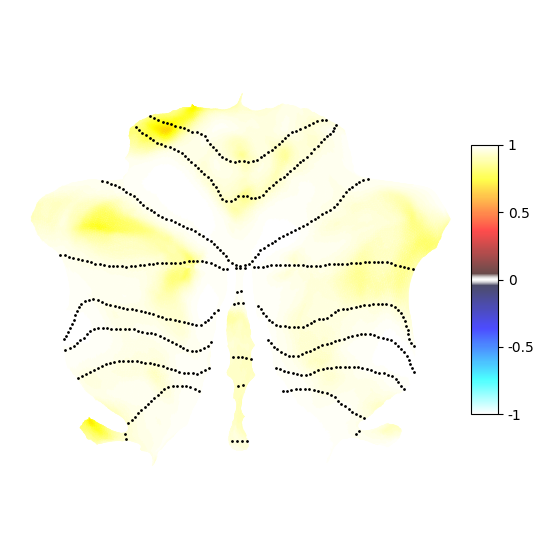

In [17]:
from SUITPy import flatmap
from mreyemove.analysis.searchlight_correlation import surface_searchlight_correlation
from pathlib import Path
from mreyemove.plotting.glm import custom_cmap


for state_1 in ("", "_W", "_S"):
    print(f"=== Head Motion Controls Raw vs Clean for {state_1} ===")
    output_dir = Path("/Users/zach/2025_RA/matthias/final images/group_level/head_motion_controls/cerebellum")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"combined_correlation_map"
    # vol_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="raw-original-sleep-cer-cov-flame")    
    vol_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="conv-fd-sleep-cer-cov-flame")    
    vol_b,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="clean-original-sleep-incl-nrem3-cer-cov-flame")

    

    # title = f"searchlight_surface_hmc_{state_1}_{state_2}_{radius_mm}"
    

# vol_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove_{state_1}", desc_add=desc_add)
# vol_b,_ = mrio.load_FLAME_result(contrast=f"mreyemove_{state_2}", desc_add=desc_add)

# vol_a,_ = mrio.load_FLAME_result(contrast=f"eog_{state_1}", desc_add=desc_add)
# vol_b,_ = mrio.load_FLAME_result(contrast=f"eog_{state_2}", desc_add=desc_add)

    
    surf_a = flatmap.vol_to_surf(vol_a.t_stat, space='FSL')
    surf_b = flatmap.vol_to_surf(vol_b.t_stat, space='FSL')
    
    results = surface_searchlight_correlation(
        map_a_surf=surf_a,
        map_b_surf=surf_b,
        neighborhoods=neighbourhoods,
        min_vertices=10,
    )

ax = flatmap.plot(data=results, cmap=custom_cmap(), 
        new_figure=True, 
        colorbar=True, 
        render='matplotlib',
        cscale=[-1.0, 1.0])
# ax.set_title(title)
# 
# output_path = output_dir / f"{title}.png"
# 
# ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")

